# Project 2: Screen Time and Sleep Duration
## Assignment 3 — Dhirubhai Ambani University | Advanced Statistical Tools for Data Science
**Research Question:** Does screen time before bedtime predict sleep duration among DAU students?  
**Data:** n = 30 students (pilot survey, March 2026) · Paired observations: Exam Week & Regular Week


In [7]:
# ── Setup ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from scipy.stats import t as t_dist, norm
import warnings
warnings.filterwarnings('ignore')

# Plot style
BLUE='#1F4E79'; MID='#2E74B5'; ACCENT='#4BACC6'; GRAY='#595959'; RED='#C00000'; GREEN='#375623'
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelcolor': GRAY, 'axes.titleweight': 'bold',
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
})
print("Setup complete.")

Setup complete.


In [8]:
# ── Load & Clean Data ────────────────────────────────────────────────
df = pd.read_excel("C:\\Users\\srrml\\Desktop\\SEMESTER 2\\ASSIGNMENTS\\Advanced Statistics\\Assignment-3\\data.xlsx")
df.columns = [
    'Timestamp','Username','RollNo','Age','Gender','Year','Programme',
    'ST_exam','Sleep_exam','Workload_exam','Caffeine_exam','Stress_exam','PA_exam',
    'ST_reg','Sleep_reg','Workload_reg','Caffeine_reg','Stress_reg','PA_reg'
]
# Recode "5 or more" -> 5 for Caffeine
df['Caffeine_exam'] = pd.to_numeric(
    df['Caffeine_exam'].replace('5 or more', 5), errors='coerce').fillna(5).astype(int)

# Binary encode Physical Activity
df['PA_exam_bin'] = (df['PA_exam'].str.strip() == 'Yes').astype(int)
df['PA_reg_bin']  = (df['PA_reg'].str.strip()  == 'Yes').astype(int)

n = len(df)
print(f"Dataset loaded: n = {n} observations")
print(f"Year distribution:\n{df['Year'].value_counts().to_string()}")
print(f"\nSummary statistics:")
df[['ST_exam','Sleep_exam','ST_reg','Sleep_reg']].describe().round(2)

Dataset loaded: n = 30 observations
Year distribution:
Year
2nd year         9
1st year         8
3rd year         8
Previous year    5

Summary statistics:


,ST_exam,Sleep_exam,ST_reg,Sleep_reg
count,30.00,30.00,30.00,30.00
mean,150.13,5.63,133.30,6.78
std,131.62,1.70,66.39,1.50
min,10.00,2.00,20.00,2.00
25%,60.00,5.00,100.00,6.00
50%,100.00,5.50,120.00,7.00
75%,230.00,6.50,162.75,7.50
max,540.00,11.00,360.00,10.00


---
## 1. Descriptive Statistics & Scatter Plots

  Exam Week: β₀=5.8361, β₁=-0.001351, r=-0.1048, p=0.5816, R²=0.0110
  Regular Week: β₀=6.8543, β₁=-0.000532, r=-0.0235, p=0.9017, R²=0.0006


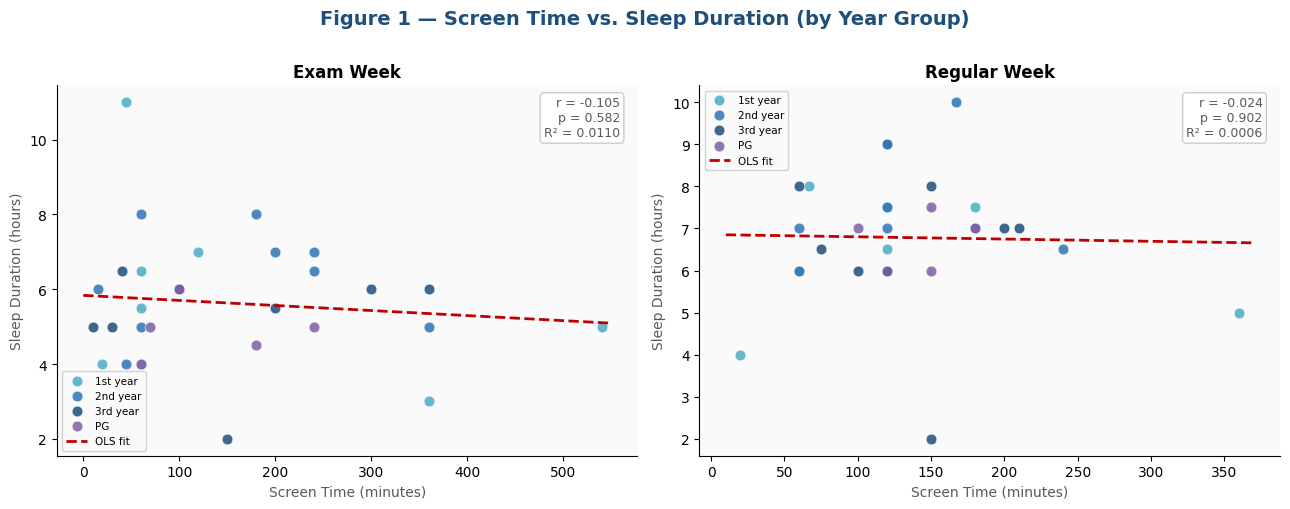

In [9]:
# ── Figure 1: Scatter Plots ──────────────────────────────────────────
# Model: Sleep = β₀ + β₁·ScreenTime + ε
# Pearson correlation: r = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / √[Σ(xᵢ-x̄)² · Σ(yᵢ-ȳ)²]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1 — Screen Time vs. Sleep Duration (by Year Group)',
             fontsize=14, fontweight='bold', color=BLUE, y=1.01)

year_colors = {'1st year':'#4BACC6','2nd year':'#2E74B5','3rd year':'#1F4E79','Previous year':'#7F5EA3'}

for ax, (col_st, col_sl, label) in zip(axes, [
        ('ST_exam','Sleep_exam','Exam Week'), ('ST_reg','Sleep_reg','Regular Week')]):
    x = df[col_st]; y = df[col_sl]
    for yr, grp in df.groupby('Year'):
        ax.scatter(grp[col_st], grp[col_sl],
                   color=year_colors.get(yr,'gray'), s=60, alpha=0.85, edgecolors='white',
                   linewidth=0.5, label=yr.replace('Previous year','PG'))
    m, b, r, p, se = stats.linregress(x, y)
    xs = np.linspace(x.min()-10, x.max()+10, 200)
    ax.plot(xs, m*xs+b, color=RED, linewidth=2, linestyle='--', label=f'OLS fit')
    ax.set_xlabel('Screen Time (minutes)', fontsize=10)
    ax.set_ylabel('Sleep Duration (hours)', fontsize=10)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=7.5, framealpha=0.85)
    ax.text(0.97, 0.97, f'r = {r:.3f}\np = {p:.3f}\nR² = {r**2:.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9, color=GRAY,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCC'))
    print(f"  {label}: β₀={b:.4f}, β₁={m:.6f}, r={r:.4f}, p={p:.4f}, R²={r**2:.4f}")

plt.tight_layout()
plt.savefig('fig1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

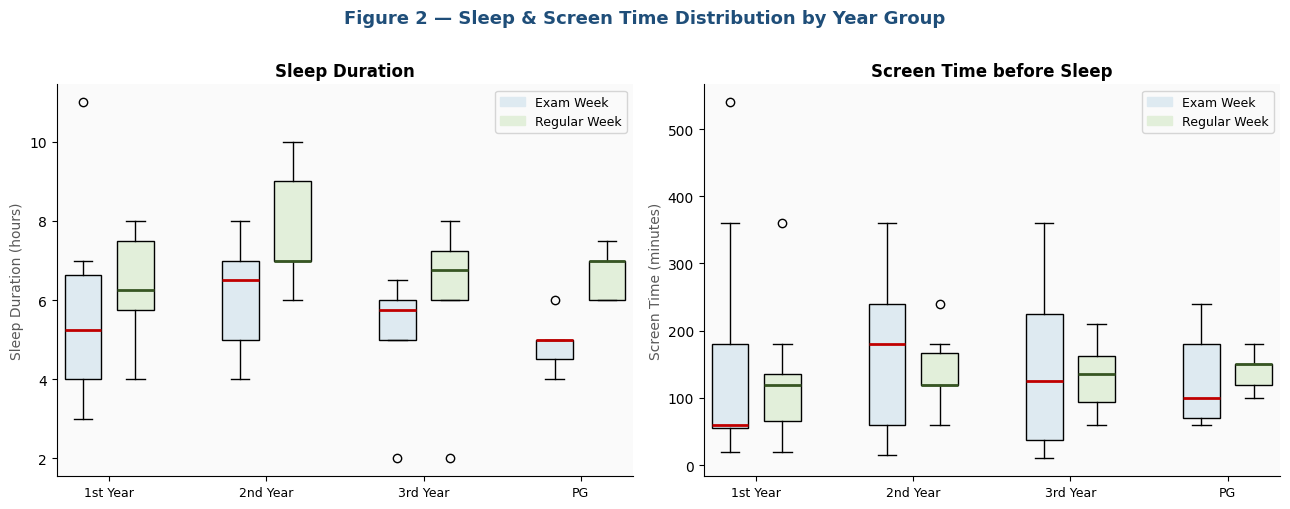

In [10]:
# ── Figure 2: Box Plots by Year Group ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2 — Sleep & Screen Time Distribution by Year Group',
             fontsize=13, fontweight='bold', color=BLUE, y=1.01)

yr_order = ['1st year','2nd year','3rd year','Previous year']
yr_labels = ['1st Year','2nd Year','3rd Year','PG']

for ax, (col_e, col_r, ylabel, title) in zip(axes, [
        ('Sleep_exam','Sleep_reg','Sleep Duration (hours)','Sleep Duration'),
        ('ST_exam','ST_reg','Screen Time (minutes)','Screen Time before Sleep')]):
    pos_e = np.arange(len(yr_order)) * 3
    pos_r = pos_e + 1.0
    d_e = [df[df['Year']==yr][col_e].dropna().values for yr in yr_order]
    d_r = [df[df['Year']==yr][col_r].dropna().values for yr in yr_order]
    bp1 = ax.boxplot(d_e, positions=pos_e, widths=0.7, patch_artist=True,
                     medianprops=dict(color=RED, linewidth=2))
    bp2 = ax.boxplot(d_r, positions=pos_r, widths=0.7, patch_artist=True,
                     medianprops=dict(color=GREEN, linewidth=2))
    for p in bp1['boxes']: p.set_facecolor('#DEEAF1')
    for p in bp2['boxes']: p.set_facecolor('#E2EFDA')
    ax.set_xticks(pos_e+0.5); ax.set_xticklabels(yr_labels, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10); ax.set_title(title, fontsize=12)
    p1 = mpatches.Patch(color='#DEEAF1', label='Exam Week', edgecolor=MID)
    p2 = mpatches.Patch(color='#E2EFDA', label='Regular Week', edgecolor=GREEN)
    ax.legend(handles=[p1,p2], fontsize=9)

plt.tight_layout()
plt.savefig('fig2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Simple Linear Regression (SLR)
**Model:** `Sleep = β₀ + β₁·ScreenTime + ε`

**Estimation (OLS):**  
β̂₁ = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / Σ(xᵢ - x̄)²  
β̂₀ = ȳ - β̂₁·x̄  

**Standard Error of β̂₁:**  
SE(β̂₁) = √[MSE / Σ(xᵢ - x̄)²]  where  MSE = SSE/(n-2)  

**t-statistic:**  t = β̂₁ / SE(β̂₁)  ~  t(n-2) under H₀: β₁ = 0  

**R²:**  R² = 1 - SSE/SST  =  r²  (for SLR)

In [11]:
# ── Simple Linear Regression ─────────────────────────────────────────
results = {}
for condition, x_col, y_col in [('Exam Week','ST_exam','Sleep_exam'),
                                  ('Regular Week','ST_reg','Sleep_reg')]:
    x = df[x_col]; y = df[y_col]
    n_obs = len(x)
    # Manual OLS
    x_bar, y_bar = x.mean(), y.mean()
    Sxx = ((x - x_bar)**2).sum()
    Sxy = ((x - x_bar)*(y - y_bar)).sum()
    b1 = Sxy / Sxx                    # β̂₁
    b0 = y_bar - b1 * x_bar          # β̂₀
    y_hat = b0 + b1*x
    SSE   = ((y - y_hat)**2).sum()
    SST   = ((y - y_bar)**2).sum()
    MSE   = SSE / (n_obs - 2)
    SE_b1 = np.sqrt(MSE / Sxx)
    t_stat = b1 / SE_b1
    from scipy.stats import t as t_dist
    p_val  = 2 * t_dist.sf(abs(t_stat), df=n_obs-2)
    R2 = 1 - SSE/SST
    RMSE = np.sqrt(MSE)
    r = np.corrcoef(x, y)[0,1]
    
    results[condition] = dict(b0=b0, b1=b1, SE_b1=SE_b1, t=t_stat, p=p_val, R2=R2, RMSE=RMSE, r=r)
    print(f"\n{'='*50}")
    print(f"{condition}")
    print(f"  β̂₀ (intercept)  = {b0:.4f}")
    print(f"  β̂₁ (screen)     = {b1:.6f}")
    print(f"  SE(β̂₁)          = {SE_b1:.6f}")
    print(f"  t-statistic      = {t_stat:.4f}")
    print(f"  p-value          = {p_val:.4f}")
    print(f"  R²               = {R2:.4f}")
    print(f"  RMSE             = {RMSE:.4f} hrs")
    print(f"  Pearson r        = {r:.4f}")


Exam Week
  β̂₀ (intercept)  = 5.8361
  β̂₁ (screen)     = -0.001351
  SE(β̂₁)          = 0.002422
  t-statistic      = -0.5575
  p-value          = 0.5816
  R²               = 0.0110
  RMSE             = 1.7170 hrs
  Pearson r        = -0.1048

Regular Week
  β̂₀ (intercept)  = 6.8543
  β̂₁ (screen)     = -0.000532
  SE(β̂₁)          = 0.004271
  t-statistic      = -0.1246
  p-value          = 0.9017
  R²               = 0.0006
  RMSE             = 1.5272 hrs
  Pearson r        = -0.0235


---
## 3. Regression Diagnostics

Influential observations (Cook's D > 0.133):
  Obs 6: Cook's D = 0.1467, ST=360, Sleep=3.0
  Obs 7: Cook's D = 0.2893, ST=44, Sleep=11.0


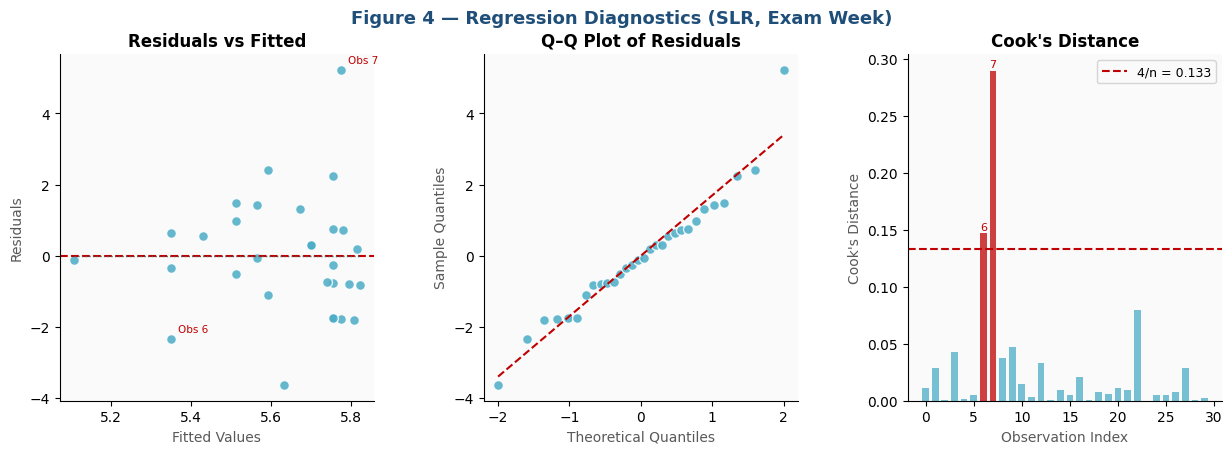

In [12]:
# ── Figure 4: Diagnostics for SLR (Exam Week) ───────────────────────
x = df['ST_exam']; y = df['Sleep_exam']
X_sm = sm.add_constant(x)
model_slr = OLS(y, X_sm).fit()
fitted    = model_slr.fittedvalues
resid     = model_slr.resid
influence = model_slr.get_influence()
cooks_d   = influence.cooks_distance[0]
threshold = 4 / n

fig = plt.figure(figsize=(15, 4.5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)
fig.suptitle('Figure 4 — Regression Diagnostics (SLR, Exam Week)',
             fontsize=13, fontweight='bold', color=BLUE)

# Residuals vs Fitted
ax1 = fig.add_subplot(gs[0])
ax1.scatter(fitted, resid, color=ACCENT, edgecolors='white', s=50, alpha=0.85)
ax1.axhline(0, color=RED, linewidth=1.5, linestyle='--')
z = np.polyfit(fitted, resid, 1)
xs = np.linspace(fitted.min(), fitted.max(), 100)
ax1.plot(xs, np.polyval(z, xs), color=GRAY, linewidth=1, linestyle=':')
ax1.set_xlabel('Fitted Values'); ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted')
for i in np.where(cooks_d > threshold)[0]:
    ax1.annotate(f'Obs {i}', (fitted.iloc[i], resid.iloc[i]),
                 fontsize=7.5, color=RED, xytext=(5,5), textcoords='offset points')

# Q-Q Plot  
# Checks normality: standardized residuals plotted against N(0,1) quantiles
ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, r_qq) = stats.probplot(resid, dist='norm')
ax2.scatter(osm, osr, color=ACCENT, edgecolors='white', s=50, alpha=0.85)
ql = np.array([min(osm), max(osm)])
ax2.plot(ql, slope*ql+intercept, color=RED, linewidth=1.5, linestyle='--')
ax2.set_xlabel('Theoretical Quantiles'); ax2.set_ylabel('Sample Quantiles')
ax2.set_title('Q–Q Plot of Residuals')

# Cook's Distance
# Dᵢ = eᵢ² / (p·MSE) · hᵢᵢ/(1-hᵢᵢ)²  where hᵢᵢ = leverage
ax3 = fig.add_subplot(gs[2])
colors_cd = [RED if d > threshold else ACCENT for d in cooks_d]
ax3.bar(range(n), cooks_d, color=colors_cd, alpha=0.75, width=0.7)
ax3.axhline(threshold, color=RED, linewidth=1.5, linestyle='--', label=f'4/n = {threshold:.3f}')
for i in np.where(cooks_d > threshold)[0]:
    ax3.annotate(f'{i}', (i, cooks_d[i]+0.003), fontsize=8, color=RED, ha='center')
ax3.set_xlabel('Observation Index'); ax3.set_ylabel("Cook's Distance")
ax3.set_title("Cook's Distance")
ax3.legend(fontsize=9)

print(f"Influential observations (Cook's D > {threshold:.3f}):")
for i in np.where(cooks_d > threshold)[0]:
    print(f"  Obs {i}: Cook's D = {cooks_d[i]:.4f}, ST={df['ST_exam'].iloc[i]}, Sleep={df['Sleep_exam'].iloc[i]}")

plt.tight_layout()
plt.savefig('fig3_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Multiple Linear Regression (MLR)
**Model:** `Sleep = β₀ + β₁·Screen + β₂·Workload + β₃·Caffeine + β₄·PhysActivity + ε`

**Matrix form:** β̂ = (XᵀX)⁻¹Xᵀy

**Adjusted R²:** R²ₐdⱼ = 1 - (1 - R²)·(n-1)/(n-k-1)


MLR — Exam Week
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.2742      1.093      5.742      0.000       4.024       8.525
ST            -0.0013      0.003     -0.483      0.633      -0.007       0.004
WL            -0.0694      0.099     -0.699      0.491      -0.274       0.135
CAF            0.0087      0.230      0.038      0.970      -0.466       0.483
PA             0.2426      0.988      0.246      0.808      -1.793       2.278
  R² = 0.0404  |  Adj. R² = -0.1131

MLR — Regular Week
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3207      1.035      7.074      0.000       5.189       9.452
ST             0.0006      0.005      0.134      0.895      -0.009       0.010
WL            -0.1327      0.116     -1.139      0.265    

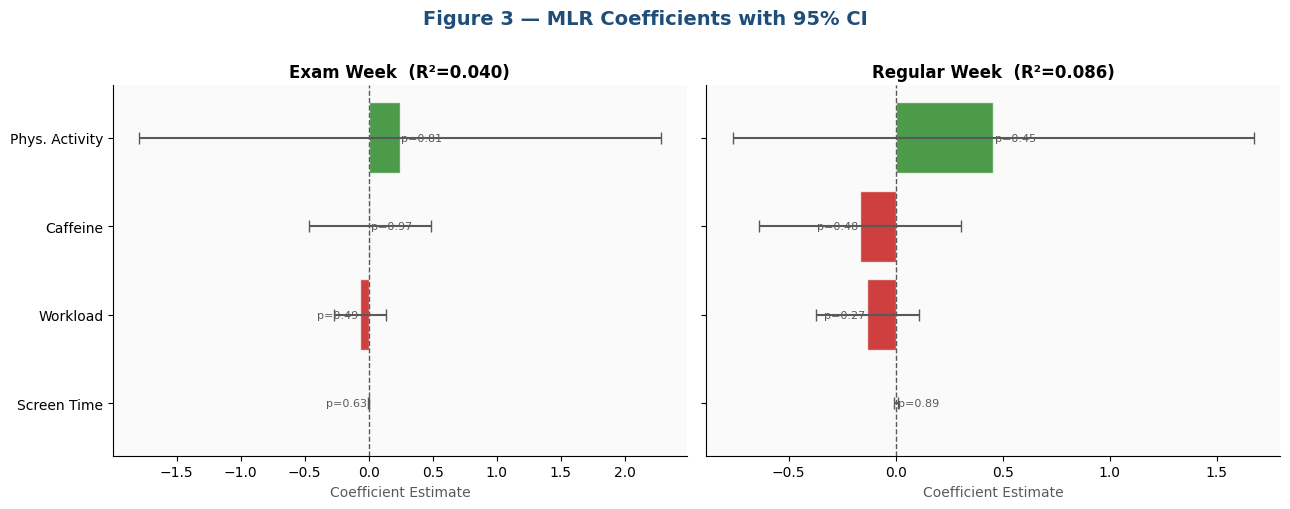

In [13]:
# ── Multiple Linear Regression ───────────────────────────────────────
for condition, st_col, sl_col, wl_col, caf_col, pa_col in [
        ('Exam Week',  'ST_exam','Sleep_exam','Workload_exam','Caffeine_exam','PA_exam_bin'),
        ('Regular Week','ST_reg', 'Sleep_reg', 'Workload_reg', 'Caffeine_reg', 'PA_reg_bin')]:
    
    X = sm.add_constant(pd.DataFrame({
        'ST':  df[st_col],
        'WL':  df[wl_col],
        'CAF': df[caf_col].astype(float),
        'PA':  df[pa_col]
    }))
    model = OLS(df[sl_col], X).fit()
    print(f"\n{'='*55}")
    print(f"MLR — {condition}")
    print(model.summary().tables[1])
    print(f"  R² = {model.rsquared:.4f}  |  Adj. R² = {model.rsquared_adj:.4f}")

# Figure 3: MLR Coefficients
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Figure 3 — MLR Coefficients with 95% CI', fontsize=14, fontweight='bold', color=BLUE, y=1.01)

for ax, (st_col,sl_col,wl_col,caf_col,pa_col,title) in zip(axes,[
        ('ST_exam','Sleep_exam','Workload_exam','Caffeine_exam','PA_exam_bin','Exam Week'),
        ('ST_reg', 'Sleep_reg', 'Workload_reg', 'Caffeine_reg', 'PA_reg_bin','Regular Week')]):
    X = sm.add_constant(pd.DataFrame({'ST':df[st_col],'WL':df[wl_col],
                                       'CAF':df[caf_col].astype(float),'PA':df[pa_col]}))
    m = OLS(df[sl_col], X).fit()
    coefs = m.params[1:]; cis = m.conf_int()[1:]
    errs = [coefs.values - cis[0].values, cis[1].values - coefs.values]
    colors_bar = [RED if c < 0 else '#107C10' for c in coefs.values]
    y_pos = np.arange(4)
    ax.barh(y_pos, coefs.values, xerr=errs, color=colors_bar, alpha=0.75,
            edgecolor='white', error_kw=dict(ecolor=GRAY, capsize=4))
    ax.axvline(0, color=GRAY, linewidth=1, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(['Screen Time','Workload','Caffeine','Phys. Activity'], fontsize=10)
    ax.set_xlabel('Coefficient Estimate', fontsize=10)
    ax.set_title(f'{title}  (R²={m.rsquared:.3f})', fontsize=12)
    for j,(v,p) in enumerate(zip(coefs.values,m.pvalues[1:])):
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else f'p={p:.2f}'
        ax.text(v+(0.01 if v>=0 else -0.01), j, sig, va='center',
                ha='left' if v>=0 else 'right', fontsize=8, color=GRAY)

plt.tight_layout()
plt.savefig('fig4_mlr_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Missing Data Analysis
**Simulated scenario:** 5 observations missing for screen time

**Mean Imputation:** Replace missing xᵢ with x̄ = (1/m)·Σᵢ∈observed xᵢ  
**Listwise Deletion:** Remove rows where xᵢ is missing

Simulated missing indices: [27 15 23 17  8]

Method                          β₀           β₁       R²     n
------------------------------------------------------------
Full data (baseline)        5.8361    -0.001351   0.0110    30
Listwise deletion           5.9218    -0.001933   0.0240    25
Mean imputation             5.9352    -0.001933   0.0215    30


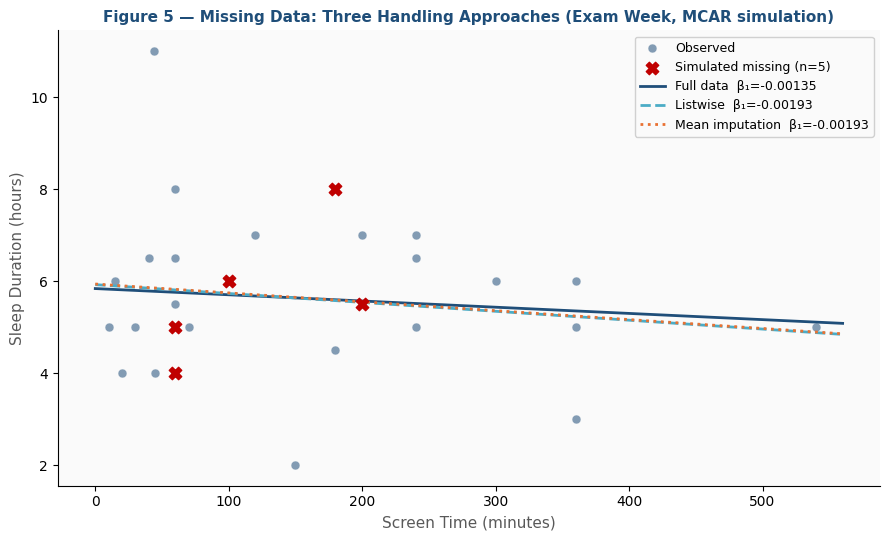

In [14]:
# ── Missing Data: Three Approaches ──────────────────────────────────
np.random.seed(42)
missing_idx = np.random.choice(n, 5, replace=False)
print(f"Simulated missing indices: {missing_idx}")

x_full = df['ST_exam'].values.astype(float)
y_full = df['Sleep_exam'].values.astype(float)

# 1. Full data
m_full, b_full, r_f, p_f, _ = stats.linregress(x_full, y_full)

# 2. Listwise deletion (complete case analysis)
mask = np.ones(n, dtype=bool); mask[missing_idx] = False
m_list, b_list, r_l, p_l, _ = stats.linregress(x_full[mask], y_full[mask])

# 3. Mean imputation: x̄_obs = mean of observed values
x_mi = x_full.copy()
x_mi[missing_idx] = x_full[mask].mean()
m_mi, b_mi, r_m, p_m, _ = stats.linregress(x_mi, y_full)

print(f"\n{'Method':<25} {'β₀':>8} {'β₁':>12} {'R²':>8} {'n':>5}")
print("-"*60)
print(f"{'Full data (baseline)':<25} {b_full:>8.4f} {m_full:>12.6f} {r_f**2:>8.4f} {n:>5}")
print(f"{'Listwise deletion':<25} {b_list:>8.4f} {m_list:>12.6f} {r_l**2:>8.4f} {mask.sum():>5}")
print(f"{'Mean imputation':<25} {b_mi:>8.4f} {m_mi:>12.6f} {r_m**2:>8.4f} {n:>5}")

# Figure 5
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x_full, y_full, color=BLUE, s=40, alpha=0.55, edgecolors='white', linewidth=0.4, label='Observed')
ax.scatter(x_full[missing_idx], y_full[missing_idx], color=RED, s=80, marker='X', zorder=5, label='Simulated missing (n=5)')
xs = np.linspace(0, x_full.max()+20, 200)
ax.plot(xs, m_full*xs+b_full,  color=BLUE,    linewidth=2,   label=f'Full data  β₁={m_full:.5f}')
ax.plot(xs, m_list*xs+b_list,  color=ACCENT,  linewidth=2, linestyle='--', label=f'Listwise  β₁={m_list:.5f}')
ax.plot(xs, m_mi*xs+b_mi,      color='#E97132', linewidth=2, linestyle=':', label=f'Mean imputation  β₁={m_mi:.5f}')
ax.set_xlabel('Screen Time (minutes)', fontsize=11)
ax.set_ylabel('Sleep Duration (hours)', fontsize=11)
ax.set_title('Figure 5 — Missing Data: Three Handling Approaches (Exam Week, MCAR simulation)', fontsize=11, fontweight='bold', color=BLUE)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('fig5_missing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Causal DAG

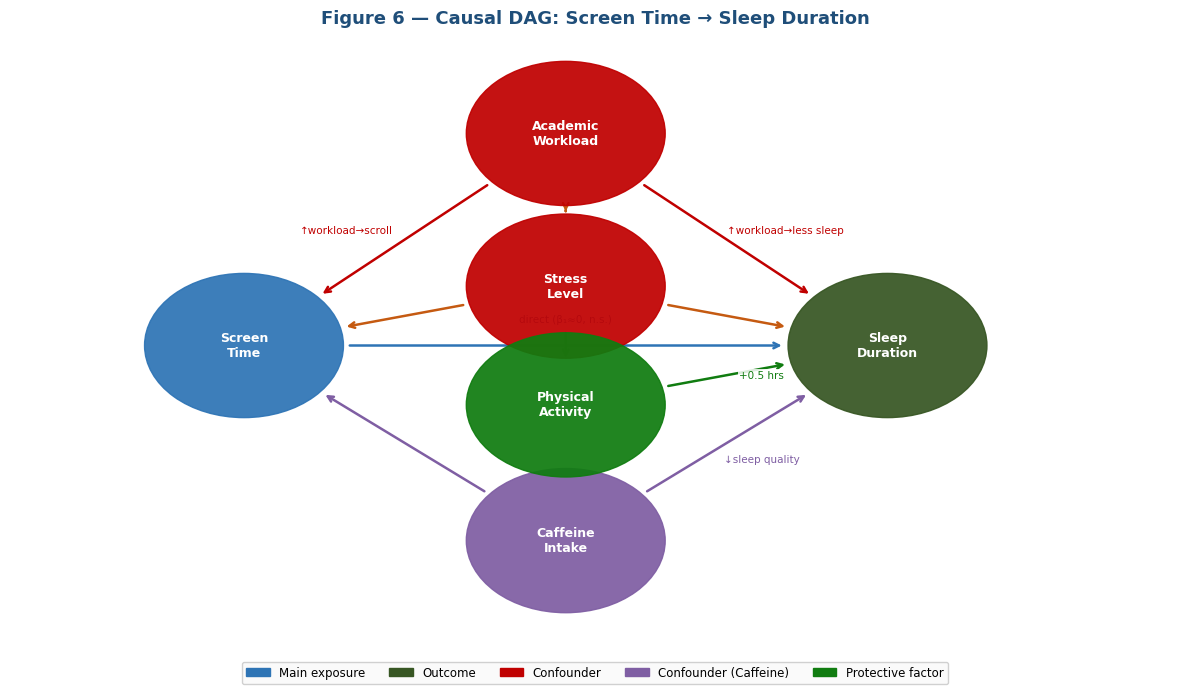

In [15]:
# ── Figure 6: Causal DAG ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0,10); ax.set_ylim(0,7); ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_title('Figure 6 — Causal DAG: Screen Time → Sleep Duration',
             fontsize=13, fontweight='bold', color=BLUE, pad=18)

nodes = {
    'Screen\nTime':       (2.0, 3.5),
    'Sleep\nDuration':    (7.5, 3.5),
    'Academic\nWorkload': (4.75, 6.0),
    'Caffeine\nIntake':   (4.75, 1.2),
    'Stress\nLevel':      (4.75, 4.2),
    'Physical\nActivity': (4.75, 2.8),
}
node_colors = {'Screen\nTime':MID,'Sleep\nDuration':'#375623',
               'Academic\nWorkload':RED,'Caffeine\nIntake':'#7F5EA3',
               'Stress\nLevel':RED,'Physical\nActivity':'#107C10'}

def draw_node(text, xy, color):
    ax.add_patch(plt.Circle(xy, 0.85, color=color, zorder=3, alpha=0.93))
    ax.text(xy[0], xy[1], text, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white', zorder=4, multialignment='center')

def arrow(src, dst, col='#888', label='', offset=(0,0)):
    nx,ny=nodes[src]; ex,ey=nodes[dst]
    dx,dy=ex-nx,ey-ny; d=np.sqrt(dx**2+dy**2)
    sx=nx+0.88*dx/d; sy=ny+0.88*dy/d
    ex2=ex-0.88*dx/d; ey2=ey-0.88*dy/d
    ax.annotate('', xy=(ex2,ey2), xytext=(sx,sy),
        arrowprops=dict(arrowstyle='->', color=col, lw=1.8))
    if label:
        mx=(sx+ex2)/2+offset[0]; my=(sy+ey2)/2+offset[1]
        ax.text(mx,my,label,ha='center',va='center',fontsize=7.5,color=col,
                bbox=dict(fc='white',ec='none',alpha=0.85,pad=1))

arrow('Screen\nTime','Sleep\nDuration', col=MID, label='direct (β₁≈0, n.s.)', offset=(0,0.3))
arrow('Academic\nWorkload','Screen\nTime',  col=RED, label='↑workload→scroll', offset=(-0.5,0.1))
arrow('Academic\nWorkload','Sleep\nDuration',col=RED, label='↑workload→less sleep', offset=(0.5,0.1))
arrow('Academic\nWorkload','Stress\nLevel',  col='#C55A11')
arrow('Stress\nLevel','Screen\nTime',        col='#C55A11')
arrow('Stress\nLevel','Sleep\nDuration',     col='#C55A11')
arrow('Caffeine\nIntake','Screen\nTime',     col='#7F5EA3')
arrow('Caffeine\nIntake','Sleep\nDuration',  col='#7F5EA3', label='↓sleep quality', offset=(0.3,-0.2))
arrow('Physical\nActivity','Sleep\nDuration',col='#107C10', label='+0.5 hrs', offset=(0.3,0))
arrow('Physical\nActivity','Stress\nLevel',  col='#107C10')

for name, pos in nodes.items(): draw_node(name, pos, node_colors[name])

legend_items = [
    mpatches.Patch(color=MID,      label='Main exposure'),
    mpatches.Patch(color='#375623',label='Outcome'),
    mpatches.Patch(color=RED,      label='Confounder'),
    mpatches.Patch(color='#7F5EA3',label='Confounder (Caffeine)'),
    mpatches.Patch(color='#107C10',label='Protective factor'),
]
ax.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.5,-0.08),
          ncol=5, fontsize=8.5, framealpha=0.9, edgecolor='#CCC')
plt.tight_layout()
plt.savefig('fig6_dag.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Sample Size Determination
**Objective:** Use the pilot (n=30) to determine the required sample size for adequate power.

**Formula (t-test for correlation):**  
Non-centrality parameter: λ = r·√(n−2) / √(1−r²)  
Power = P(|T| > t_{α/2, n−2} | λ)  

**Note:** Due to constraints of time and resources, we could only collect n=30 for this pilot study. The sample satisfies the Central Limit Theorem (CLT requires n ≥ 30), ensuring approximate normality of the sampling distribution of β̂₁, which validates the use of t-based inference even without assuming normality in the raw data.

Pilot correlation (Exam Week): r = -0.1048
|r| = 0.1048  (effect size for power calculation)

Required sample size for 80% power: n = 711
Required sample size for 90% power: n = 951
Statistical power at n=30 (pilot):  8.1%

CLT justification: n=30 satisfies the CLT threshold (≥30),
so β̂₁ ~ Normal even without normality of raw residuals.


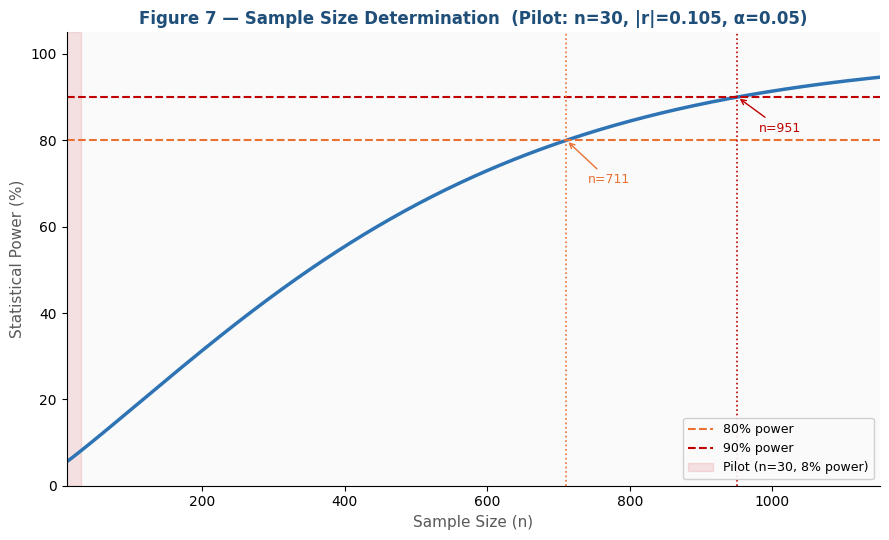

In [16]:
# ── Sample Size Determination ────────────────────────────────────────
# Pilot estimate of effect size
r_pilot = stats.linregress(df['ST_exam'], df['Sleep_exam']).rvalue
r_abs   = abs(r_pilot)
alpha   = 0.05

print(f"Pilot correlation (Exam Week): r = {r_pilot:.4f}")
print(f"|r| = {r_abs:.4f}  (effect size for power calculation)")

n_range = np.arange(10, 1200)
powers  = []
for ni in n_range:
    # Non-centrality parameter for t-test on correlation
    lam    = r_abs * np.sqrt(ni - 2) / np.sqrt(max(1 - r_abs**2, 1e-10))
    t_crit = t_dist.ppf(1 - alpha/2, df=ni - 2)
    pwr    = (1 - t_dist.cdf(t_crit, df=ni-2, loc=lam)
              +   t_dist.cdf(-t_crit, df=ni-2, loc=lam))
    powers.append(pwr)
powers = np.array(powers)

idx80 = np.where(powers >= 0.80)[0]
idx90 = np.where(powers >= 0.90)[0]
n_80  = int(n_range[idx80[0]]) if len(idx80) > 0 else ">1200"
n_90  = int(n_range[idx90[0]]) if len(idx90) > 0 else ">1200"
pwr30 = powers[30 - 10] * 100

print(f"\nRequired sample size for 80% power: n = {n_80}")
print(f"Required sample size for 90% power: n = {n_90}")
print(f"Statistical power at n=30 (pilot):  {pwr30:.1f}%")
print(f"\nCLT justification: n=30 satisfies the CLT threshold (≥30),")
print(f"so β̂₁ ~ Normal even without normality of raw residuals.")

# Figure 7
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_end = min(int(n_90)+200 if isinstance(n_90,int) else 1200, 1200)
ax.plot(n_range[:plot_end-10], powers[:plot_end-10]*100, color=MID, linewidth=2.5)
ax.axhline(80, color='#E97132', linewidth=1.5, linestyle='--', label='80% power')
ax.axhline(90, color=RED,       linewidth=1.5, linestyle='--', label='90% power')
if isinstance(n_80,int): ax.axvline(n_80, color='#E97132', linewidth=1.2, linestyle=':')
if isinstance(n_90,int): ax.axvline(n_90, color=RED,       linewidth=1.2, linestyle=':')
ax.axvspan(0, 30, alpha=0.10, color=RED, label=f'Pilot (n=30, {pwr30:.0f}% power)')
if isinstance(n_80,int):
    ax.annotate(f'n={n_80}', xy=(n_80,80), xytext=(n_80+30,70),
                arrowprops=dict(arrowstyle='->',color='#E97132'), fontsize=9, color='#E97132')
if isinstance(n_90,int):
    ax.annotate(f'n={n_90}', xy=(n_90,90), xytext=(n_90+30,82),
                arrowprops=dict(arrowstyle='->',color=RED), fontsize=9, color=RED)
ax.set_xlabel('Sample Size (n)', fontsize=11)
ax.set_ylabel('Statistical Power (%)', fontsize=11)
ax.set_title(f'Figure 7 — Sample Size Determination  (Pilot: n=30, |r|={r_abs:.3f}, α=0.05)',
             fontsize=12, fontweight='bold', color=BLUE)
ax.legend(fontsize=9, framealpha=0.9)
ax.set_xlim(10, plot_end); ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('fig7_samplesize.png', dpi=150, bbox_inches='tight')
plt.show()